In [1]:
!pip install librosa soundfile matplotlib seaborn tensorflow scikit-learn pandas

  Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl (350.8 MB)
  Using cached absl_py-2.5.0-py3-none-any.whl (137 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl (26 kB)
  Using cached gast-0.7.0-py3-none-any.whl (22 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl (26.4 MB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl (71 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl (439 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl (7.7 kB)
     -------------------------------------- 80.9/80.9 kB 565.6 kB/s eta 0:00:00
     ---------------------------------------- 5.2/5.2 MB 1.3 MB/s eta 0:00:00
     ---------------------------------------- 2.4/2.4 MB 1.9 MB/s eta 0:00:00
  Using cached h5py-3.14.0-cp311-cp311-win_amd64.whl (2.9 MB)
  Using cached ml_dtypes-0.5.4-cp311-cp311-win_amd64.whl (210 kB)
  Using cached namex-0.1.0-p


[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Masking
from tensorflow.keras.utils import to_categorical

In [3]:
import os

dataset_path = "audio_speech_actors_01-24"

emotion_dict = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

files = []
labels = []

for actor in sorted(os.listdir(dataset_path)):

    actor_path = os.path.join(dataset_path, actor)

    if not os.path.isdir(actor_path):
        continue

    for file in os.listdir(actor_path):

        if file.endswith(".wav"):

            emotion = file.split("-")[2]

            files.append(os.path.join(actor_path, file))

            labels.append(emotion_dict[emotion])

print("Total audio files:", len(files))

print("Emotion classes:", sorted(set(labels)))

Total audio files: 1440
Emotion classes: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


                                                File  Emotion
0  audio_speech_actors_01-24\Actor_01\03-01-01-01...  neutral
1  audio_speech_actors_01-24\Actor_01\03-01-01-01...  neutral
2  audio_speech_actors_01-24\Actor_01\03-01-01-01...  neutral
3  audio_speech_actors_01-24\Actor_01\03-01-01-01...  neutral
4  audio_speech_actors_01-24\Actor_01\03-01-02-01...     calm

Samples per class:

Emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64


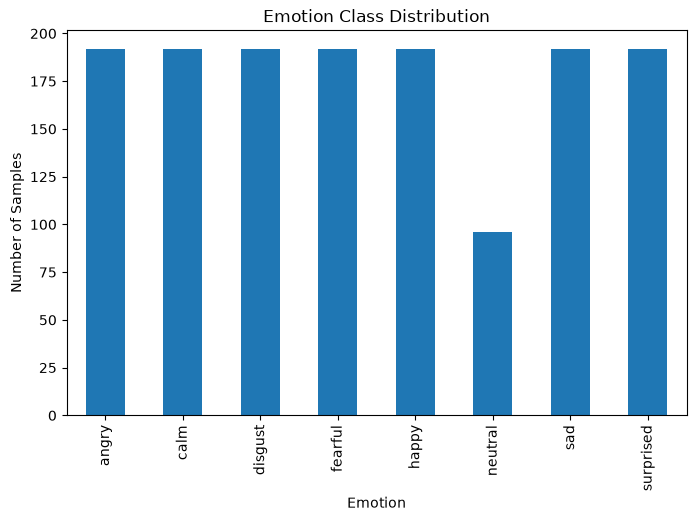

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "File": files,
    "Emotion": labels
})

print(df.head())

print("\nSamples per class:\n")
print(df["Emotion"].value_counts())

plt.figure(figsize=(8,5))

df["Emotion"].value_counts().sort_index().plot(kind="bar")

plt.title("Emotion Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")

plt.show()

In [5]:
max_len=200

X=[]

for file in files:

    y,sr=librosa.load(file,sr=16000)

    mfcc=librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=40
    )

    mfcc=mfcc.T

    if mfcc.shape[0]<max_len:

        pad=max_len-mfcc.shape[0]

        mfcc=np.pad(
            mfcc,
            ((0,pad),(0,0))
        )

    else:

        mfcc=mfcc[:max_len,:]

    X.append(mfcc)

X=np.array(X)

print(X.shape)

c:\Tejeswar\embedUR_assignments\embedUR_AIML_assignments\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(1440, 200, 40)


In [6]:
encoder=LabelEncoder()

y=encoder.fit_transform(labels)

y=to_categorical(y)

print(y.shape)

(1440, 8)


In [7]:
X_train,X_test,y_train,y_test=train_test_split(

X,

y,

test_size=0.2,

random_state=42,

stratify=y

)

print(X_train.shape)

print(X_test.shape)

(1152, 200, 40)
(288, 200, 40)


In [8]:
model=Sequential()

model.add(

Masking(mask_value=0,input_shape=(200,40))

)

model.add(

LSTM(128)

)

model.add(

Dropout(0.3)

)

model.add(

Dense(64,activation="relu")

)

model.add(

Dense(8,activation="softmax")

)

model.compile(

optimizer="adam",

loss="categorical_crossentropy",

metrics=["accuracy"]

)

model.summary()

c:\Tejeswar\embedUR_assignments\embedUR_AIML_assignments\venv\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 200, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        86,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,304 (372.28 KB)

 Trainable params: 95,304 (372.28 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history=model.fit(

X_train,

y_train,

epochs=50,

batch_size=32,

validation_split=0.2

)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.1412 - loss: 2.1009 - val_accuracy: 0.1299 - val_loss: 2.0632
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.1444 - loss: 2.0558 - val_accuracy: 0.2078 - val_loss: 2.0341
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.1922 - loss: 2.0361 - val_accuracy: 0.2468 - val_loss: 2.0035
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.1900 - loss: 2.0118 - val_accuracy: 0.2900 - val_loss: 1.9590
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.2313 - loss: 1.9600 - val_accuracy: 0.1991 - val_loss: 1.9499
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.2302 - loss: 1.9292 - val_accuracy: 0.2987 - val_loss: 1.8498
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.2866 - loss: 1.8544 - val_accuracy: 0.3506 - val_loss: 1.7857
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.3203 - loss: 1.8030 - val_accuracy: 0.3636 - v

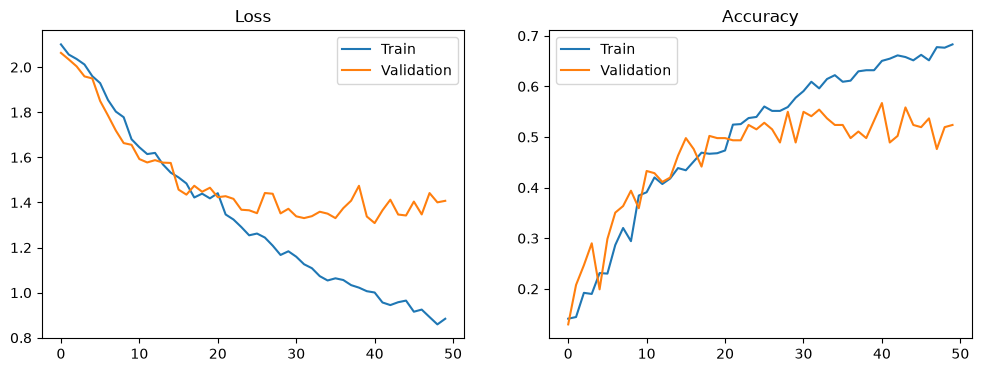

In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Train","Validation"])

plt.title("Loss")

plt.subplot(1,2,2)

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.title("Accuracy")

plt.show()

In [11]:
pred=model.predict(X_test)

pred=np.argmax(pred,axis=1)

true=np.argmax(y_test,axis=1)

print("Accuracy")

print(accuracy_score(true,pred))

print()

print(classification_report(

true,

pred,

target_names=encoder.classes_

))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Accuracy
0.5069444444444444

              precision    recall  f1-score   support

       angry       0.76      0.67      0.71        39
        calm       0.68      0.71      0.69        38
     disgust       0.53      0.54      0.53        39
     fearful       0.70      0.41      0.52        39
       happy       0.41      0.50      0.45        38
     neutral       0.39      0.37      0.38        19
         sad       0.29      0.24      0.26        38
   surprised       0.38      0.55      0.45        38

    accuracy                           0.51       288
   macro avg       0.52      0.50      0.50       288
weighted avg       0.53      0.51      0.51       288



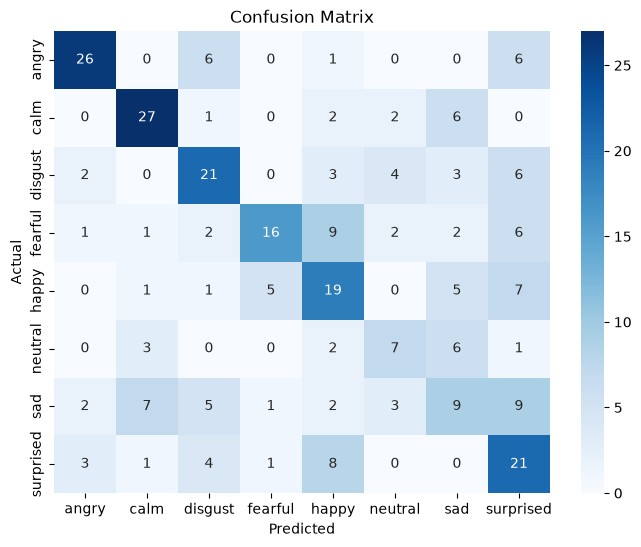

In [12]:
cm=confusion_matrix(true,pred)

plt.figure(figsize=(8,6))

sns.heatmap(

cm,

annot=True,

fmt="d",

xticklabels=encoder.classes_,

yticklabels=encoder.classes_,

cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()